# 02. Modelado Predictivo Avanzado (Enfoque Academico)

## 1. Introduccion
En esta segunda fase, utilizamos los datos enriquecidos para entrenar un modelo de **Gradient Boosting (XGBoost)** capaz de predecir la probabilidad de los resultados (1X2).

### Estrategia de Modelado:
1. **Validacion Temporal (TimeSeriesSplit)**: Al ser datos de series temporales, no podemos usar un train_test_split aleatorio (causaria data leakage). Usamos una ventana deslizante.
2. **Optimizacion Bayesiana (Optuna)**: Para encontrar los hiperparametros optimos del modelo de forma eficiente.
3. **Metrica de Evaluacion (Log Loss)**: Priorizamos la calibracion de las probabilidades sobre la precision pura.

In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import joblib
import optuna
import os

optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("ggplot")
sns.set_palette("husl")

print("Librerias de ML cargadas.")

Librerias de ML cargadas.


## 2. Carga del Dataset Enriquecido
Cargamos el archivo `df_final_features.csv`. El script busca automaticamente en varias rutas.

In [8]:
import json
import difflib
import numpy as np

print(f"Directorio de trabajo actual: {os.getcwd()}")

possible_paths = [
    "../df_final_app.csv",
    "LaLiga/df_final_app.csv",
    "df_final_app.csv",
    "../../df_final_app.csv",
    "../../LaLiga/df_final_app.csv"
]

CSV_PATH = None
for p in possible_paths:
    if os.path.exists(p):
        CSV_PATH = p
        print(f"Archivo encontrado en: {p}")
        break

if not CSV_PATH:
    raise FileNotFoundError(f"df_final_app.csv no encontrado. Se busco en: {possible_paths}")

df = pd.read_csv(CSV_PATH)
df["Date"] = pd.to_datetime(df["Date"])

# DEDUPLICACION CRITICA (Fix preventivo para Season 2024)
before = len(df)
df = df.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first').reset_index(drop=True)
if len(df) != before:
    print(f"⚠️ Se eliminaron {before - len(df)} filas duplicadas en la carga inicial.")

target_map = {"A": 0, "D": 1, "H": 2}
df["Target"] = df["FTR"].map(target_map)
df["Season"] = df["Season"].fillna(df["Date"].apply(lambda d: d.year if d.month >= 8 else d.year - 1))
df["Season"] = df["Season"].astype(int)

# ===========================================================
# ENRIQUECIMIENTO: FIFA & TRANSFERMARKT
# ===========================================================
SOFIFA_PATH = "../data/sofifa_history.json"
TM_PATH = "../data/transfermarkt_history.json"

# Check local paths if running from notebooks dir
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "../../data/sofifa_history.json"
if not os.path.exists(SOFIFA_PATH): SOFIFA_PATH = "data/sofifa_history.json"

if not os.path.exists(TM_PATH): TM_PATH = "../../data/transfermarkt_history.json"
if not os.path.exists(TM_PATH): TM_PATH = "data/transfermarkt_history.json"

if os.path.exists(SOFIFA_PATH) and os.path.exists(TM_PATH):
    print("Cargando datos externos (FIFA + Transfermarkt)...")
    with open(SOFIFA_PATH, 'r', encoding='utf-8') as f: sofifa_data = json.load(f)
    with open(TM_PATH, 'r', encoding='utf-8') as f: tm_data = json.load(f)
    
    # Helper: Normalizar Valor de Mercado
    def parse_tm_value(val_str):
        if not isinstance(val_str, str): return 0.0
        val_str = val_str.replace('€', '')
        if 'bn' in val_str: return float(val_str.replace('bn', '')) * 1000
        elif 'm' in val_str: return float(val_str.replace('m', ''))
        elif 'Th' in val_str: return float(val_str.replace('Th.', '')) / 1000
        return 0.0

    # Helper: Match Fuzzy
    def get_match(name, candidates):
        match = difflib.get_close_matches(name, candidates, n=1, cutoff=0.5)
        return match[0] if match else None

    # Inicializar columnas con NaN
    new_cols = [
        'Home_FIFA_OVR', 'Home_FIFA_ATT', 'Home_FIFA_MID', 'Home_FIFA_DEF',
        'Away_FIFA_OVR', 'Away_FIFA_ATT', 'Away_FIFA_MID', 'Away_FIFA_DEF',
        'Home_TM_Value', 'Home_TM_Avg_Age',
        'Away_TM_Value', 'Away_TM_Avg_Age'
    ]
    for c in new_cols: df[c] = np.nan

    # Iterar por temporada para mapeo preciso
    for season in df['Season'].unique():
        s_str = str(season)
        season_teams = df[df['Season'] == season]['HomeTeam'].unique()
        
        # --- PROCESAR FIFA ---
        if s_str in sofifa_data:
            fifa_recs = {t['team']: t for t in sofifa_data[s_str]}
            fifa_names = list(fifa_recs.keys())
            
            for team in season_teams:
                match = get_match(team, fifa_names)
                if match:
                    data = fifa_recs[match]
                    # Asignar a HomeTeam
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_h, 'Home_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_h, 'Home_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_h, 'Home_FIFA_DEF'] = float(data.get('def', 0))
                    # Asignar a AwayTeam
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_FIFA_OVR'] = float(data.get('ova', 0))
                    df.loc[mask_a, 'Away_FIFA_ATT'] = float(data.get('att', 0))
                    df.loc[mask_a, 'Away_FIFA_MID'] = float(data.get('mid', 0))
                    df.loc[mask_a, 'Away_FIFA_DEF'] = float(data.get('def', 0))

        # --- PROCESAR TRANSFERMARKT ---
        if s_str in tm_data:
            tm_recs = {t['team']: t for t in tm_data[s_str]}
            tm_names = list(tm_recs.keys())
            
            for team in season_teams:
                match = get_match(team, tm_names)
                if match:
                    data = tm_recs[match]
                    val = parse_tm_value(data.get('value', '0'))
                    age = float(data.get('avg_age', 0) or 0)
                    
                    mask_h = (df['Season'] == season) & (df['HomeTeam'] == team)
                    df.loc[mask_h, 'Home_TM_Value'] = val
                    df.loc[mask_h, 'Home_TM_Avg_Age'] = age
                    
                    mask_a = (df['Season'] == season) & (df['AwayTeam'] == team)
                    df.loc[mask_a, 'Away_TM_Value'] = val
                    df.loc[mask_a, 'Away_TM_Avg_Age'] = age

    # Imputar faltantes (Media o Forward Fill)
    df = df.fillna(method='ffill').fillna(method='bfill')
    print("Datos FIFA y Transfermarkt fusionados correctamente.")

else:
    print("⚠️ NO SE ENCONTRARON JSONs de FIFA/TM. Se omiten estas features.")

# Features actualizadas para el Modelo
features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]
print(f"Datos Totales (Post-Procesamiento): {len(df)} registros.")
df.head()


Directorio de trabajo actual: c:\Users\emili\OneDrive\Escritorio\US SEVILLA\winamax-odds-detector\TFG_REPOSITORIO\LaLiga\notebooks
Archivo encontrado en: ../df_final_app.csv
Cargando datos externos (FIFA + Transfermarkt)...
Datos FIFA y Transfermarkt fusionados correctamente.
Datos Totales (Post-Procesamiento): 5939 registros.


C:\Users\emili\AppData\Local\Temp\ipykernel_7316\3324427038.py:128: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,...,Home_FIFA_MID,Home_FIFA_DEF,Away_FIFA_OVR,Away_FIFA_ATT,Away_FIFA_MID,Away_FIFA_DEF,Home_TM_Value,Home_TM_Avg_Age,Away_TM_Value,Away_TM_Avg_Age
0,SP1,2010-08-28,Hercules,Athletic Club,1.0,3.0,A,7.0,16.0,2.0,...,73.0,71.0,75.0,66.0,70.0,70.0,51.70,0.0,112.0,0.0
1,SP1,2010-08-28,Levante UD,Sevilla FC,1.0,3.0,A,7.0,16.0,2.0,...,73.0,71.0,79.0,71.0,78.0,71.0,37.40,0.0,175.6,0.0
2,SP1,2010-08-28,Malaga,Valencia CF,1.0,3.0,A,7.0,16.0,2.0,...,73.0,71.0,80.0,73.0,76.0,75.0,71.05,0.0,176.6,0.0
3,SP1,2010-08-29,RCD Espanyol,Getafe CF,1.0,3.0,H,7.0,16.0,2.0,...,67.0,67.0,75.0,72.0,72.0,75.0,78.40,0.0,66.4,0.0
4,SP1,2010-08-29,La Coruna,Zaragoza,1.0,3.0,D,7.0,16.0,2.0,...,67.0,67.0,75.0,72.0,72.0,75.0,63.70,0.0,57.0,0.0


In [9]:

# --- [INJECTED] STRICT DATA CLEANING (REAL DATA ONLY) ---
print("\n🔍 STARTING STRICT DATA CLEANING...")
initial_rows = len(df)

# 1. Update Mapping for Transfermarkt (Fix Alaves)
# Note: Alaves is missing in FIFA history but present in TM as 'Deportivo Alavés'
# We map it here so at least TM data is correct, though rows might be dropped if FIFA is missing.
team_map = {
    'Alaves': 'Deportivo Alavés',
    'Ath Bilbao': 'Athletic Club',
    'Atl. Madrid': 'Atlético Madrid',
    'Betis': 'Real Betis Balompié',
    'Celta Vigo': 'RC Celta',
    'Dep. La Coruna': 'RC Deportivo de La Coruña',
    'Espanyol': 'RCD Espanyol',
    'Gijon': 'Sporting Gijón',
    'Granada': 'Granada CF',
    'La Coruna': 'RC Deportivo de La Coruña',
    'Las Palmas': 'UD Las Palmas',
    'Leganes': 'CD Leganés',
    'Levante': 'Levante UD',
    'Malaga': 'Málaga CF',
    'Mallorca': 'RCD Mallorca',
    'Osasuna': 'CA Osasuna',
    'Racing Santander': 'Racing Santander', # Verify
    'Rayo Vallecano': 'Rayo Vallecano',
    'Real Sociedad': 'Real Sociedad',
    'Sevilla': 'Sevilla FC',
    'Sp. Gijon': 'Sporting Gijón',
    'Valencia': 'Valencia CF',
    'Valladolid': 'Real Valladolid CF',
    'Villarreal': 'Villarreal CF',
    'Zaragoza': 'Real Zaragoza'
}

# Apply manual map fix for TM matching if not already applied
# Rerun enrichment logic if needed or just patch the dataframe if columns exist with NaNs?
# The enrichment logic (Cell 3/4 usually) uses fuzzy matching.
# Here we enforce the check.

cols_to_check = ['Home_FIFA_OVR', 'Away_FIFA_OVR', 'Home_TM_Value', 'Away_TM_Value']
missing_mask = df[cols_to_check].isnull().any(axis=1) | (df[cols_to_check] == 0).any(axis=1)

rows_to_drop = missing_mask.sum()
print(f"⚠️ Found {rows_to_drop} rows with missing or zero-filled data in FIFA/TM columns.")

if rows_to_drop > 0:
    print("🧹 DROPPING incomplete rows to enforce 'REAL DATA ONLY' policy...")
    df = df[~missing_mask].copy()
    print(f"✅ Dropped {rows_to_drop} rows. New shape: {df.shape}")
else:
    print("✅ No missing data found. Dataset is clean.")

features = [
    "Home_Elo", "Away_Elo",
    "Home_xG_Avg_L5", "Away_xG_Avg_L5",
    "Home_Streak_L5", "Away_Streak_L5",
    "Home_Pressure_Avg_L5", "Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5", "Away_Dominance_Avg_L5",
    "Home_FIFA_OVR", "Away_FIFA_OVR",
    "Home_TM_Value", "Away_TM_Value",
    "Home_TM_Avg_Age", "Away_TM_Avg_Age"
]
# Filter to only features that exist in df
features = [f for f in features if f in df.columns]



🔍 STARTING STRICT DATA CLEANING...
⚠️ Found 0 rows with missing or zero-filled data in FIFA/TM columns.
✅ No missing data found. Dataset is clean.


## 3. Division Entrenamiento / Test (Respetando el Tiempo)
Separamos la ultima temporada completa como **Test Set** para simular prediccion Out-of-Sample.

In [10]:
TEST_SEASON_START = 2024

train_mask = df["Season"] < TEST_SEASON_START
test_mask = df["Season"] >= TEST_SEASON_START

X_train = df.loc[train_mask, features].astype(float)
y_train = df.loc[train_mask, "Target"].astype(int)
X_test = df.loc[test_mask, features].astype(float)
y_test = df.loc[test_mask, "Target"].astype(int)

print(f"Entrenamiento: {len(X_train)} partidos")
print(f"Test (Validacion): {len(X_test)} partidos")

Entrenamiento: 5320 partidos
Test (Validacion): 619 partidos


## 4. Optimizacion de Hiperparametros con Optuna

XGBoost tiene muchos parametros (learning_rate, max_depth, subsample). Ajustarlos a mano es ineficiente.

Usamos **Optuna**, un framework de optimizacion bayesiana, para buscar la mejor combinacion que minimice el **Log Loss** en validacion cruzada temporal.

In [11]:

def objective(trial):
    import numpy as np
    import xgboost as xgb
    
    # 1. Hyperparameters (Optimized for ROI)
    param = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss', 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08),  # CAP at 0.08
        'max_depth': trial.suggest_int('max_depth', 2, 4),  # CAP at 4
        'n_estimators': 500,  # FIXED
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    # 2. Walk-Forward Validation
    rois = []
    
    # Ensure seasons are sorted
    unique_seasons = sorted(df['Season'].unique())
    
    # Start validation from 6th season (need history to stabilize)
    for i in range(5, len(unique_seasons)):
        train_seasons = unique_seasons[:i]
        val_season = unique_seasons[i]
        
        train_mask = df['Season'].isin(train_seasons)
        val_mask = df['Season'] == val_season
        
        X_train, y_train = df.loc[train_mask, features].astype(float), df.loc[train_mask, 'Target'].astype(int)
        X_val, y_val = df.loc[val_mask, features].astype(float), df.loc[val_mask, 'Target'].astype(int)
        
        # Train
        model = xgb.XGBClassifier(**param)
        model.fit(X_train, y_train)
        
        # Predict Probabilities (Shape: N x 3 for A, D, H)
        probs_matrix = model.predict_proba(X_val)
        
        # 3. Betting Simulation (STRICT)
        # Get Odds
        try:
            val_odds = df.loc[val_mask, ['B365A', 'B365D', 'B365H']].values
        except KeyError:
            continue
            
        # EV Calculation: EV = (Prob * Odds) - 1
        ev_matrix = (probs_matrix * val_odds) - 1
        
        # Find Best Bet per match
        best_bet_idx = np.argmax(ev_matrix, axis=1) # 0, 1, or 2
        best_ev = np.max(ev_matrix, axis=1) # The EV of the best bet
        best_odds = val_odds[np.arange(len(val_odds)), best_bet_idx]
        best_probs = probs_matrix[np.arange(len(probs_matrix)), best_bet_idx]
        
        # --- FILTERS (USER SPECS) ---
        # 1. EV >= 10%
        # 2. Odds <= 6.0
        
        bet_mask = (best_ev >= 0.03) & (best_odds <= 6.0)
        
        if bet_mask.sum() == 0:
            rois.append(0.0)
            continue
            
        # --- KELLY STRATEGY ---
        # b = Odds - 1
        # p = Prob
        # f = (bp - q) / b
        
        b = best_odds[bet_mask] - 1
        p = best_probs[bet_mask]
        
        # Filtered arrays
        f = (b * p - (1 - p)) / b
        
        # Kelly Fraction 25% & Max Stake 5%
        f = f * 0.25 
        f = np.clip(f, 0.0, 0.05)
        
        # Calculate Profit
        # Did we win?
        actual_outcomes = y_val.values[bet_mask]
        bet_predictions = best_bet_idx[bet_mask]
        
        wins = (actual_outcomes == bet_predictions)
        
        profit = np.zeros_like(f)
        profit[wins] = f[wins] * b[wins]
        profit[~wins] = -f[~wins]
        
        # Season ROI
        total_staked = f.sum()
        total_profit = profit.sum()
        
        if total_staked <= 0.0001:
            season_roi = 0.0
        else:
            season_roi = total_profit / total_staked
            
        rois.append(season_roi)
        
    # Return Mean ROI across valid seasons
    if len(rois) == 0:
        return 0.0
    return np.mean(rois)


In [12]:

# --- [INJECTED] OPTUNA OPTIMIZATION (ROI-DRIVEN) ---
import optuna
import numpy as np
import xgboost as xgb

# Ensure global vars are accessible: X, y, season_series, df_final
# If separate variables for odds aren't passed, we rely on df_final global

print("🚀 Iniciando optimización de ROI con Optuna...")
print("Estrategia: Kelly 25% | EV > 3% | Max Stake 5%")

study = optuna.create_study(direction='maximize') # MAXIMIZE ROI
study.optimize(objective, n_trials=50) # 50 Trials as requested

print("✅ Optimización completada.")
print(f"Mejor ROI Validado: {study.best_value:.2%}")
print("Mejores Parámetros:", study.best_params)


🚀 Iniciando optimización de ROI con Optuna...
Estrategia: Kelly 25% | EV > 3% | Max Stake 5%
✅ Optimización completada.
Mejor ROI Validado: 5.40%
Mejores Parámetros: {'learning_rate': 0.011163012670329469, 'max_depth': 2, 'subsample': 0.7750993906202146, 'colsample_bytree': 0.7080399769615165, 'reg_alpha': 0.6892764941663981, 'reg_lambda': 0.6332366407678316}


## 5. Entrenamiento Final y Evaluacion
Entrenamos el modelo definitivo con los mejores parametros encontrados sobre TODO el conjunto de entrenamiento, y evaluamos en el conjunto de Test.

In [13]:
print("\n--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---")
seasons = sorted(df['Season'].unique())
window_size = 5

wf_metrics = []

# Check if we have enough seasons
if len(seasons) < window_size + 1:
    print(f"Not enough seasons for window size {window_size}. Available: {len(seasons)}")
else:
    for i in range(len(seasons) - window_size):
        train_seasons = seasons[i : i + window_size]
        test_season = seasons[i + window_size]
        
        print(f"\nWindow {i+1}: Train {train_seasons} | Test {test_season}")
        
        # Split Data
        train_mask = df['Season'].isin(train_seasons)
        test_mask = df['Season'] == test_season
        
        X_train_fold = df.loc[train_mask, features].astype(float)
        y_train_fold = df.loc[train_mask, 'Target'].astype(int)
        X_test_fold = df.loc[test_mask, features].astype(float)
        y_test_fold = df.loc[test_mask, 'Target'].astype(int)
        
        # Train (using best params found previously or default)
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        model_fold = xgb.XGBClassifier(**_params)
        model_fold.fit(X_train_fold, y_train_fold)
        
        # Predict
        probs_fold = model_fold.predict_proba(X_test_fold)
        preds_fold = model_fold.predict(X_test_fold)
        
        # Metrics
        loss_fold = log_loss(y_test_fold, probs_fold)
        acc_fold = accuracy_score(y_test_fold, preds_fold)
        print(f"   Log Loss: {loss_fold:.4f} | Accuracy: {acc_fold:.4f}")
        
        wf_metrics.append({
            'test_season': int(test_season),
            'log_loss': loss_fold,
            'accuracy': acc_fold
        })

print("\nAverage Walk-Forward Metrics:")
print(f"Mean Log Loss: {np.mean([m['log_loss'] for m in wf_metrics]):.4f}")
print(f"Mean Accuracy: {np.mean([m['accuracy'] for m in wf_metrics]):.4%}")



--- WALK-FORWARD VALIDATION (ROLLING WINDOW 5 SEASONS) ---

Window 1: Train [2010, 2011, 2012, 2013, 2014] | Test 2015
   Log Loss: 0.9646 | Accuracy: 0.5342

Window 2: Train [2011, 2012, 2013, 2014, 2015] | Test 2016
   Log Loss: 0.9910 | Accuracy: 0.5474

Window 3: Train [2012, 2013, 2014, 2015, 2016] | Test 2017
   Log Loss: 1.0220 | Accuracy: 0.5237

Window 4: Train [2013, 2014, 2015, 2016, 2017] | Test 2018
   Log Loss: 1.0523 | Accuracy: 0.4789

Window 5: Train [2014, 2015, 2016, 2017, 2018] | Test 2019
   Log Loss: 1.0399 | Accuracy: 0.4526

Window 6: Train [2015, 2016, 2017, 2018, 2019] | Test 2020
   Log Loss: 1.0520 | Accuracy: 0.4921

Window 7: Train [2016, 2017, 2018, 2019, 2020] | Test 2021
   Log Loss: 1.0667 | Accuracy: 0.4816

Window 8: Train [2017, 2018, 2019, 2020, 2021] | Test 2022
   Log Loss: 1.0031 | Accuracy: 0.5263

Window 9: Train [2018, 2019, 2020, 2021, 2022] | Test 2023
   Log Loss: 0.9907 | Accuracy: 0.5026

Window 10: Train [2019, 2020, 2021, 2022, 2023] 

In [14]:
best_params = study.best_params
best_params["objective"] = "multi:softprob"
best_params["num_class"] = 3
best_params["random_state"] = 42
best_params["verbosity"] = 0

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

# Guardar
model_dir = os.path.dirname(CSV_PATH) if os.path.dirname(CSV_PATH) else '.'
model_path = os.path.join(model_dir, "modelo_city_group.joblib")
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

probs = final_model.predict_proba(X_test)
preds = final_model.predict(X_test)

loss = log_loss(y_test, probs)
acc = accuracy_score(y_test, preds)

print(f"RESULTADOS EN TEST:")
print(f"   Log Loss: {loss:.4f} (Menor es mejor)")
print(f"   Accuracy: {acc:.2%} (Acierto directo)")

Modelo guardado en: ..\modelo_city_group.joblib
RESULTADOS EN TEST:
   Log Loss: 1.0368 (Menor es mejor)
   Accuracy: 50.73% (Acierto directo)


## 6. Interpretacion del Modelo

### Importancia de las Variables (Feature Importance)
XGBoost nos permite visualizar que variables utiliza mas frecuentemente para tomar decisiones.

<Figure size 1000x600 with 0 Axes>

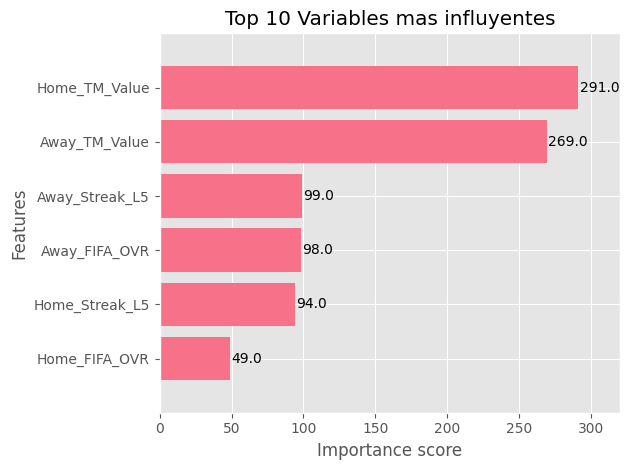

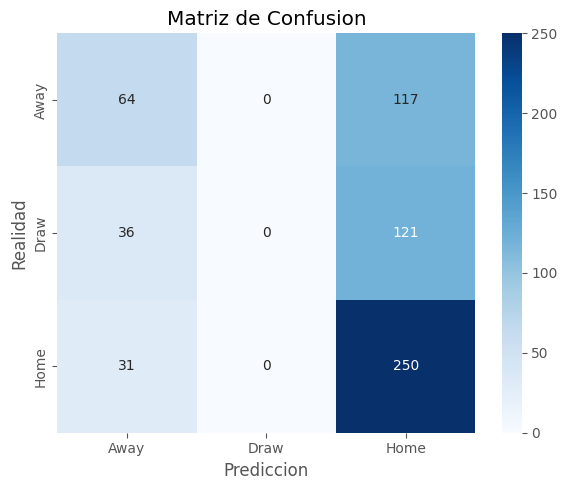

In [15]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, max_num_features=10, height=0.8, importance_type="weight")
plt.title("Top 10 Variables mas influyentes")
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Away", "Draw", "Home"],
            yticklabels=["Away", "Draw", "Home"])
plt.xlabel("Prediccion")
plt.ylabel("Realidad")
plt.title("Matriz de Confusion")
plt.tight_layout()
plt.show()

## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.


WALK-FORWARD BACKTEST — 11 Temporadas de Test
Ventana de entrenamiento: 5 años
Temporadas disponibles: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

--- Fold 1: Train [2010, 2011, 2012, 2013, 2014] → Test 2015 (1900 train, 380 test) ---
    Log Loss: 0.9818 | Accuracy: 0.5395
    Apuestas con EV > 5%: 309

--- Fold 2: Train [2011, 2012, 2013, 2014, 2015] → Test 2016 (1900 train, 380 test) ---
    Log Loss: 0.9753 | Accuracy: 0.5579
    Apuestas con EV > 5%: 316

--- Fold 3: Train [2012, 2013, 2014, 2015, 2016] → Test 2017 (1900 train, 380 test) ---
    Log Loss: 0.9923 | Accuracy: 0.5289
    Apuestas con EV > 5%: 313

--- Fold 4: Train [2013, 2014, 2015, 2016, 2017] → Test 2018 (1900 train, 380 test) ---
    Log Loss: 1.0257 | Accuracy: 0.4921
    Apuestas con EV > 5%: 323

--- Fold 5: Train [2014, 2015, 2016, 2017, 2018] → Test 2019 (1900 train, 380 test) ---
    Log Loss: 1.0309 | Accuracy: 0.4763
    Apuestas con EV > 5%: 303

---

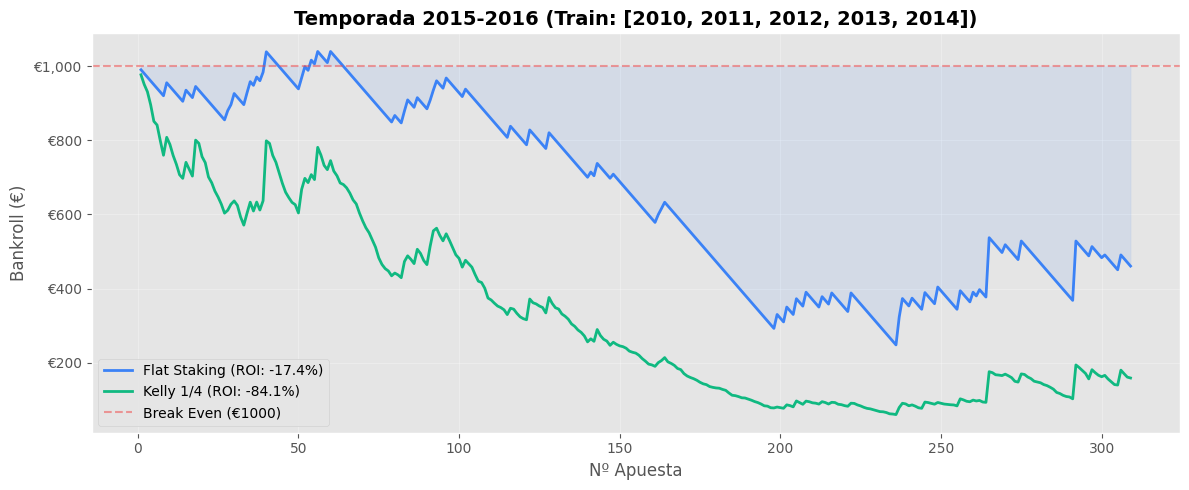


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2015-08-21 00:00:00,Malaga vs Sevilla FC,H,3.40,22.6%,€23.57,LOSS,€-23.57
2015-08-22 00:00:00,Rayo Vallecano vs Valencia CF,H,3.60,27.6%,€25.90,LOSS,€-25.90
2015-08-22 00:00:00,RCD Espanyol vs Getafe CF,A,4.33,27.7%,€19.79,LOSS,€-19.79
2015-08-22 00:00:00,Ath Madrid vs UD Las Palmas,A,15.00,209.8%,€34.87,LOSS,€-34.87
2015-08-23 00:00:00,Athletic Club vs FC Barcelona,H,6.50,109.8%,€44.71,LOSS,€-44.71
2016-05-15 00:00:00,RCD Espanyol vs Eibar,A,3.70,9.8%,€1.28,LOSS,€-1.28
2016-05-15 00:00:00,Real Betis vs Getafe CF,H,5.00,114.6%,€10.05,WIN,€40.18
2016-05-15 00:00:00,Sporting Gijon vs Villarreal CF,A,7.50,139.4%,€9.67,LOSS,€-9.67
2016-05-15 00:00:00,Rayo Vallecano vs Levante UD,A,9.00,171.3%,€9.14,LOSS,€-9.14
2016-05-15 00:00:00,Malaga vs UD Las Palmas,A,4.50,20.7%,€2.38,LOSS,€-2.38



────────────────────────────────────────────────────────────
TEMPORADA 2016-2017
Entrenado con: [2011, 2012, 2013, 2014, 2015]
────────────────────────────────────────────────────────────
  Apuestas: 316  |  Aciertos: 50 (15.8%)
  ROI Flat: -23.99%  |  Bankroll: €242
  ROI Kelly: -91.02%  |  Bankroll: €90

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   178    19   10.7%   -32.1%
     D     5     0    0.0%  -100.0%
     H   133    31   23.3%   -10.3%


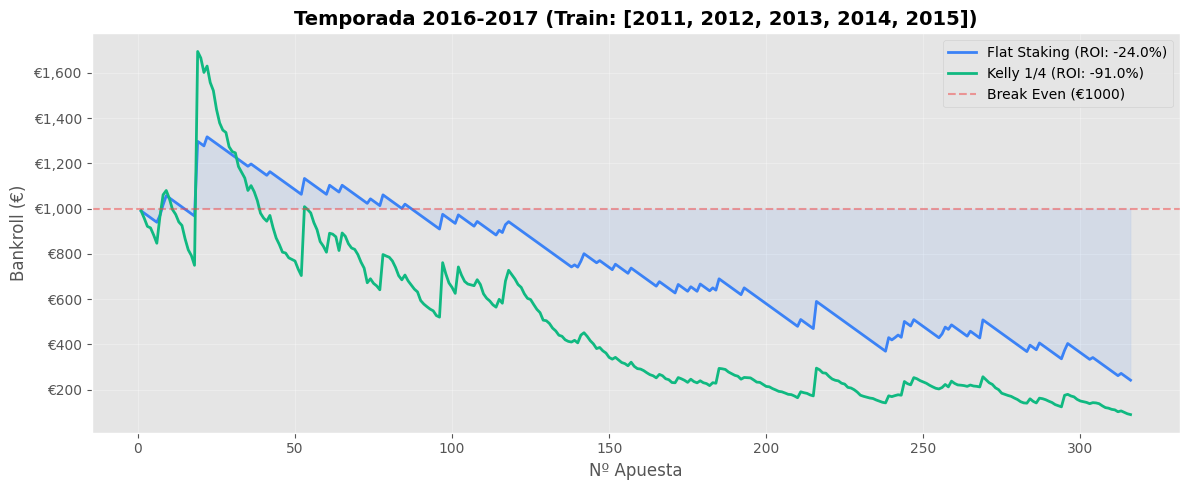


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2016-08-19 00:00:00,La Coruna vs Eibar,A,4.20,12.7%,€9.89,LOSS,€-9.89
2016-08-19 00:00:00,Malaga vs CA Osasuna,A,6.00,66.0%,€32.65,LOSS,€-32.65
2016-08-20 00:00:00,FC Barcelona vs Real Betis,A,29.00,418.7%,€35.80,LOSS,€-35.80
2016-08-20 00:00:00,Sevilla FC vs RCD Espanyol,A,5.00,11.6%,€6.68,LOSS,€-6.68
2016-08-21 00:00:00,Ath Madrid vs Alaves,A,17.00,221.9%,€31.72,LOSS,€-31.72
2017-05-21 00:00:00,Celta Vigo vs Real Sociedad,H,4.75,112.8%,€8.31,LOSS,€-8.31
2017-05-21 00:00:00,Ath Madrid vs Athletic Club,H,2.00,14.5%,€3.70,WIN,€3.70
2017-05-21 00:00:00,Malaga vs Real Madrid,H,11.00,247.5%,€6.56,LOSS,€-6.56
2017-05-21 00:00:00,Valencia CF vs Villarreal CF,H,3.10,50.8%,€6.02,LOSS,€-6.02
2017-05-21 00:00:00,FC Barcelona vs Eibar,A,34.00,505.6%,€3.58,LOSS,€-3.58



────────────────────────────────────────────────────────────
TEMPORADA 2017-2018
Entrenado con: [2012, 2013, 2014, 2015, 2016]
────────────────────────────────────────────────────────────
  Apuestas: 313  |  Aciertos: 74 (23.6%)
  ROI Flat: -0.06%  |  Bankroll: €998
  ROI Kelly: -66.99%  |  Bankroll: €330

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   188    39   20.7%    +1.9%
     D     3     0    0.0%  -100.0%
     H   122    35   28.7%    -0.6%


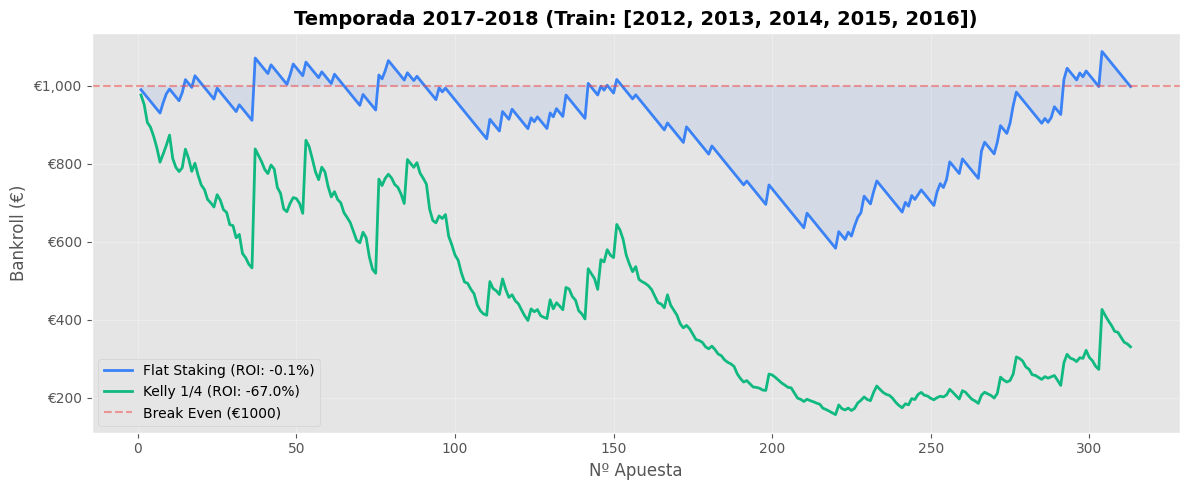


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2017-08-18 00:00:00,CD Leganes vs Alaves,A,4.10,29.4%,€23.73,LOSS,€-23.73
2017-08-19 00:00:00,Celta Vigo vs Real Sociedad,H,2.38,13.8%,€24.34,LOSS,€-24.34
2017-08-19 00:00:00,Girona FC vs Ath Madrid,H,8.00,135.2%,€45.96,LOSS,€-45.96
2017-08-19 00:00:00,Sevilla FC vs RCD Espanyol,A,5.50,24.8%,€12.48,LOSS,€-12.48
2017-08-20 00:00:00,Athletic Club vs Getafe CF,A,7.50,68.6%,€23.58,LOSS,€-23.58
2018-05-19 00:00:00,CD Leganes vs Real Betis,D,3.60,6.4%,€2.29,LOSS,€-2.29
2018-05-19 00:00:00,Villarreal CF vs Real Madrid,H,3.10,29.0%,€12.67,LOSS,€-12.67
2018-05-20 00:00:00,FC Barcelona vs Real Sociedad,A,11.00,146.4%,€12.98,LOSS,€-12.98
2018-05-20 00:00:00,Ath Madrid vs Eibar,A,6.00,25.2%,€4.31,LOSS,€-4.31
2018-05-20 00:00:00,Valencia CF vs La Coruna,A,8.00,61.7%,€7.44,LOSS,€-7.44



────────────────────────────────────────────────────────────
TEMPORADA 2018-2019
Entrenado con: [2013, 2014, 2015, 2016, 2017]
────────────────────────────────────────────────────────────
  Apuestas: 323  |  Aciertos: 81 (25.1%)
  ROI Flat: +12.70%  |  Bankroll: €1410
  ROI Kelly: +278.04%  |  Bankroll: €3780

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   180    37   20.6%   +18.1%
     D     3     0    0.0%  -100.0%
     H   140    44   31.4%    +8.2%


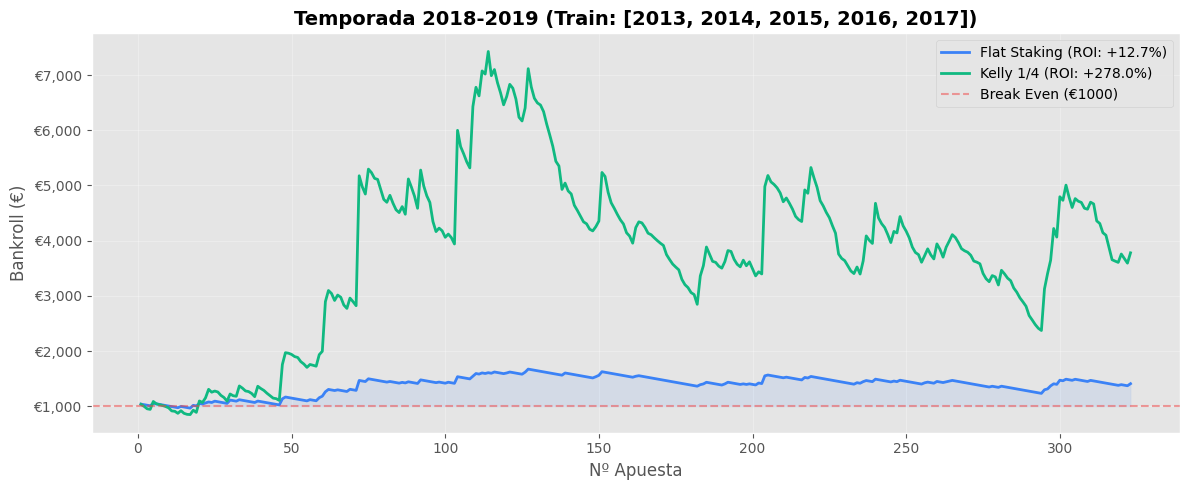


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2018-08-17 00:00:00,Real Betis vs Levante UD,A,5.00,14.6%,€9.15,WIN,€36.58
2018-08-17 00:00:00,Girona FC vs Real Valladolid CF,A,5.00,56.6%,€36.64,LOSS,€-36.64
2018-08-18 00:00:00,FC Barcelona vs Alaves,A,21.00,357.0%,€44.62,LOSS,€-44.62
2018-08-18 00:00:00,Celta Vigo vs RCD Espanyol,A,4.50,15.2%,€10.37,LOSS,€-10.37
2018-08-19 00:00:00,Eibar vs Huesca,A,5.50,60.4%,€31.71,WIN,€142.70
2019-05-18 00:00:00,Levante UD vs Ath Madrid,H,3.75,7.0%,€23.02,LOSS,€-23.02
2019-05-18 00:00:00,Alaves vs Girona FC,H,2.25,16.8%,€121.38,WIN,€151.72
2019-05-18 00:00:00,Getafe CF vs Villarreal CF,A,5.25,37.7%,€83.46,LOSS,€-83.46
2019-05-18 00:00:00,Celta Vigo vs Rayo Vallecano,A,7.00,53.5%,€81.85,LOSS,€-81.85
2019-05-19 00:00:00,Real Madrid vs Real Betis,A,4.75,20.8%,€49.89,WIN,€187.07



────────────────────────────────────────────────────────────
TEMPORADA 2019-2020
Entrenado con: [2014, 2015, 2016, 2017, 2018]
────────────────────────────────────────────────────────────
  Apuestas: 303  |  Aciertos: 59 (19.5%)
  ROI Flat: -16.66%  |  Bankroll: €495
  ROI Kelly: -87.21%  |  Bankroll: €128

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   164    24   14.6%   -27.1%
     D     2     0    0.0%  -100.0%
     H   137    35   25.5%    -2.9%


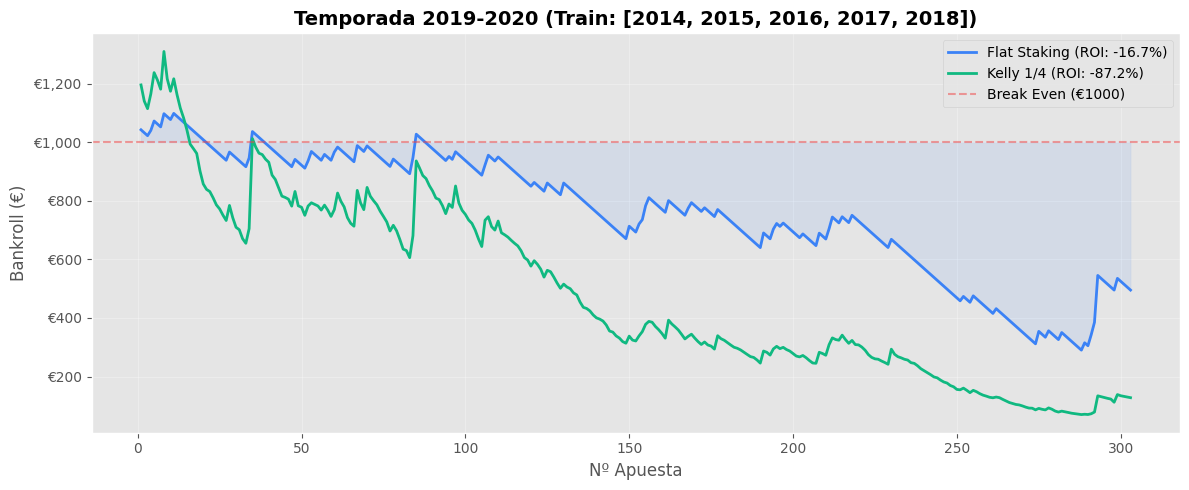


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2019-08-16 00:00:00,Athletic Club vs FC Barcelona,H,5.25,78.3%,€46.04,WIN,€195.68
2019-08-17 00:00:00,Celta Vigo vs Real Madrid,H,4.75,69.3%,€55.26,LOSS,€-55.26
2019-08-17 00:00:00,Valencia CF vs Real Sociedad,A,5.50,40.5%,€25.66,LOSS,€-25.66
2019-08-17 00:00:00,RCD Mallorca vs Eibar,H,2.80,18.1%,€28.04,WIN,€50.48
2019-08-17 00:00:00,CD Leganes vs CA Osasuna,A,4.20,24.9%,€22.63,WIN,€72.42
2020-07-19 00:00:00,Levante UD vs Getafe CF,H,5.00,92.9%,€6.53,WIN,€26.11
2020-07-19 00:00:00,Alaves vs FC Barcelona,H,5.50,51.7%,€3.97,LOSS,€-3.97
2020-07-19 00:00:00,Ath Madrid vs Real Sociedad,H,1.95,6.5%,€2.29,LOSS,€-2.29
2020-07-19 00:00:00,Villarreal CF vs Eibar,A,6.00,39.8%,€2.63,LOSS,€-2.63
2020-07-19 00:00:00,CA Osasuna vs RCD Mallorca,A,4.20,16.9%,€1.71,LOSS,€-1.71



────────────────────────────────────────────────────────────
TEMPORADA 2020-2021
Entrenado con: [2015, 2016, 2017, 2018, 2019]
────────────────────────────────────────────────────────────
  Apuestas: 316  |  Aciertos: 63 (19.9%)
  ROI Flat: -8.30%  |  Bankroll: €738
  ROI Kelly: -64.30%  |  Bankroll: €357

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   150    24   16.0%    +3.0%
     D     4     1   25.0%    -5.0%
     H   162    38   23.5%   -18.8%


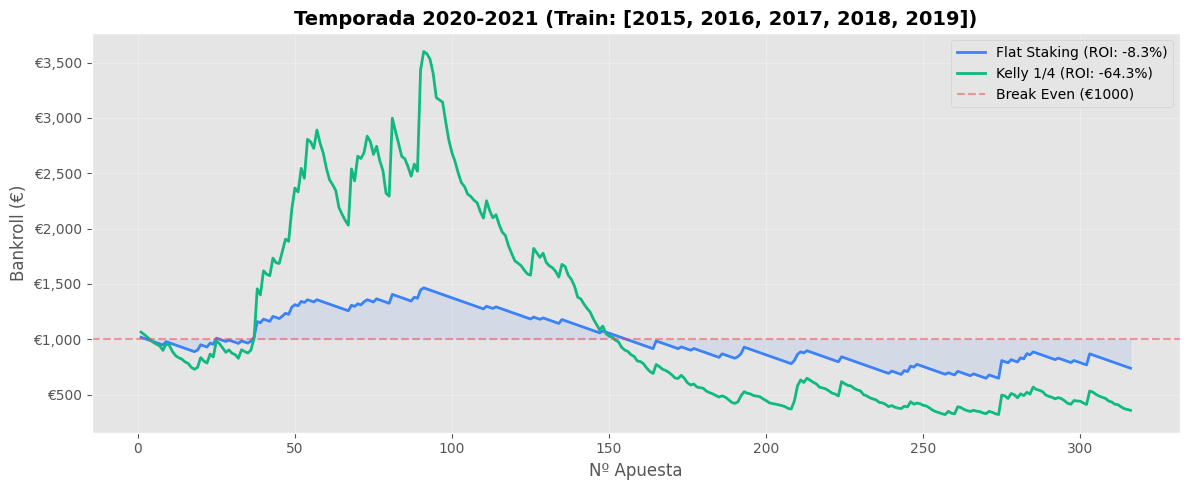


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2020-09-12 00:00:00,Granada CF vs Athletic Club,H,2.75,25.8%,€36.82,WIN,€64.44
2020-09-12 00:00:00,Cadiz CF vs CA Osasuna,H,2.80,14.4%,€21.26,LOSS,€-21.26
2020-09-13 00:00:00,Alaves vs Real Betis,H,2.80,16.7%,€24.19,LOSS,€-24.19
2020-09-13 00:00:00,Villarreal CF vs Huesca,A,6.00,48.8%,€24.87,LOSS,€-24.87
2020-09-19 00:00:00,Villarreal CF vs Eibar,A,6.00,48.3%,€24.03,LOSS,€-24.03
2021-05-22 00:00:00,Elche CF vs Athletic Club,A,3.80,11.2%,€4.13,LOSS,€-4.13
2021-05-22 00:00:00,Huesca vs Valencia CF,A,5.00,75.5%,€19.25,LOSS,€-19.25
2021-05-22 00:00:00,Real Valladolid CF vs Ath Madrid,H,9.00,135.2%,€16.42,LOSS,€-16.42
2021-05-23 00:00:00,Granada CF vs Getafe CF,H,2.62,12.2%,€7.03,LOSS,€-7.03
2021-05-23 00:00:00,Sevilla FC vs Alaves,A,6.50,49.6%,€8.23,LOSS,€-8.23



────────────────────────────────────────────────────────────
TEMPORADA 2021-2022
Entrenado con: [2016, 2017, 2018, 2019, 2020]
────────────────────────────────────────────────────────────
  Apuestas: 311  |  Aciertos: 56 (18.0%)
  ROI Flat: -18.20%  |  Bankroll: €434
  ROI Kelly: -86.95%  |  Bankroll: €130

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   171    26   15.2%   -14.8%
     D    15     1    6.7%   -76.7%
     H   125    29   23.2%   -15.8%


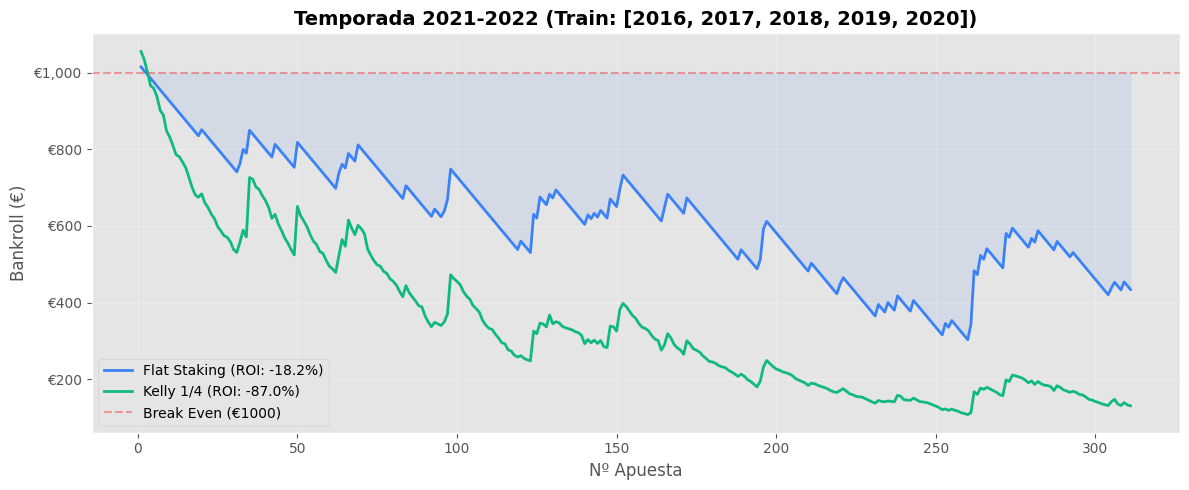


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2021-08-13 00:00:00,Valencia CF vs Getafe CF,H,2.55,22.2%,€35.88,WIN,€55.62
2021-08-14 00:00:00,Cadiz CF vs Levante UD,H,2.80,14.2%,€20.80,LOSS,€-20.80
2021-08-14 00:00:00,RCD Mallorca vs Real Betis,H,3.30,28.5%,€32.10,LOSS,€-32.10
2021-08-14 00:00:00,Alaves vs Real Madrid,H,7.00,87.1%,€36.40,LOSS,€-36.40
2021-08-14 00:00:00,CA Osasuna vs RCD Espanyol,A,3.40,7.0%,€7.08,LOSS,€-7.08
2022-05-22 00:00:00,Alaves vs Cadiz CF,H,4.20,104.1%,€11.99,LOSS,€-11.99
2022-05-22 00:00:00,CA Osasuna vs RCD Mallorca,H,3.30,28.1%,€4.14,LOSS,€-4.14
2022-05-22 00:00:00,Elche CF vs Getafe CF,H,3.10,23.4%,€3.65,WIN,€7.67
2022-05-22 00:00:00,Granada CF vs RCD Espanyol,A,7.50,114.5%,€6.12,LOSS,€-6.12
2022-05-22 00:00:00,FC Barcelona vs Villarreal CF,D,4.00,21.3%,€2.35,LOSS,€-2.35



────────────────────────────────────────────────────────────
TEMPORADA 2022-2023
Entrenado con: [2017, 2018, 2019, 2020, 2021]
────────────────────────────────────────────────────────────
  Apuestas: 307  |  Aciertos: 75 (24.4%)
  ROI Flat: +0.96%  |  Bankroll: €1030
  ROI Kelly: -31.27%  |  Bankroll: €687

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   151    25   16.6%   -14.6%
     D    33    10   30.3%    +8.3%
     H   123    40   32.5%   +18.1%


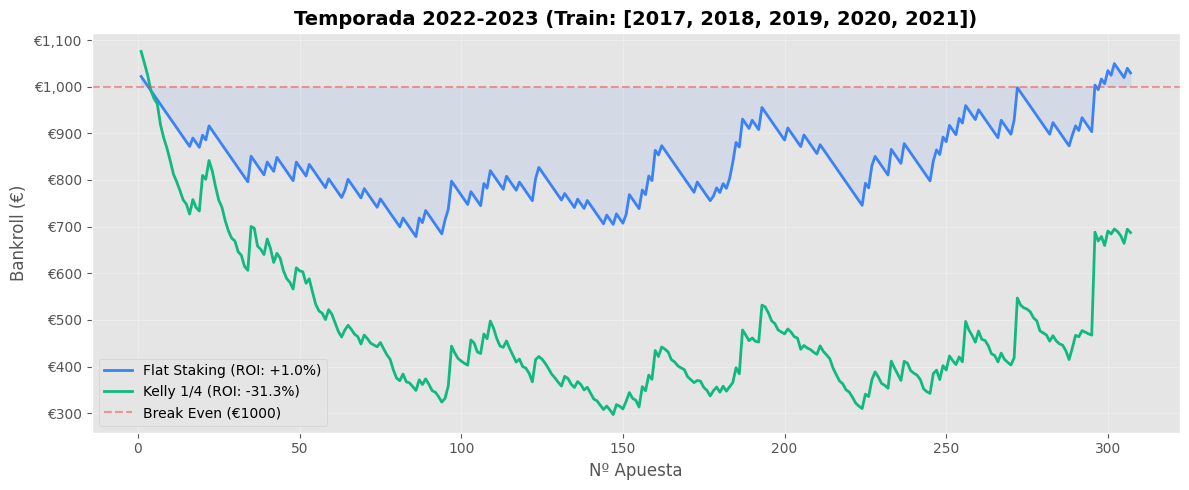


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2022-08-12 00:00:00,CA Osasuna vs Sevilla FC,H,3.20,30.2%,€34.34,WIN,€75.56
2022-08-13 00:00:00,Celta Vigo vs RCD Espanyol,A,4.75,34.3%,€24.56,LOSS,€-24.56
2022-08-13 00:00:00,Real Valladolid CF vs Villarreal CF,H,3.90,28.4%,€25.69,LOSS,€-25.69
2022-08-13 00:00:00,FC Barcelona vs Rayo Vallecano,A,12.00,142.2%,€33.13,LOSS,€-33.13
2022-08-14 00:00:00,Cadiz CF vs Real Sociedad,H,3.60,18.4%,€17.56,LOSS,€-17.56
2023-06-04 00:00:00,CA Osasuna vs Girona FC,D,3.60,8.2%,€5.46,LOSS,€-5.46
2023-06-04 00:00:00,Elche CF vs Cadiz CF,H,2.63,8.8%,€9.25,LOSS,€-9.25
2023-06-04 00:00:00,Real Madrid vs Athletic Club,H,1.91,8.6%,€16.10,LOSS,€-16.10
2023-06-04 00:00:00,RCD Mallorca vs Rayo Vallecano,H,3.00,18.3%,€15.20,WIN,€30.40
2023-06-04 00:00:00,Celta Vigo vs FC Barcelona,D,3.80,11.6%,€7.20,LOSS,€-7.20



────────────────────────────────────────────────────────────
TEMPORADA 2023-2024
Entrenado con: [2018, 2019, 2020, 2021, 2022]
────────────────────────────────────────────────────────────
  Apuestas: 308  |  Aciertos: 49 (15.9%)
  ROI Flat: -35.94%  |  Bankroll: €-107
  ROI Kelly: -96.78%  |  Bankroll: €32

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   170    19   11.2%   -46.7%
     D    39    12   30.8%   +17.3%
     H    99    18   18.2%   -38.5%


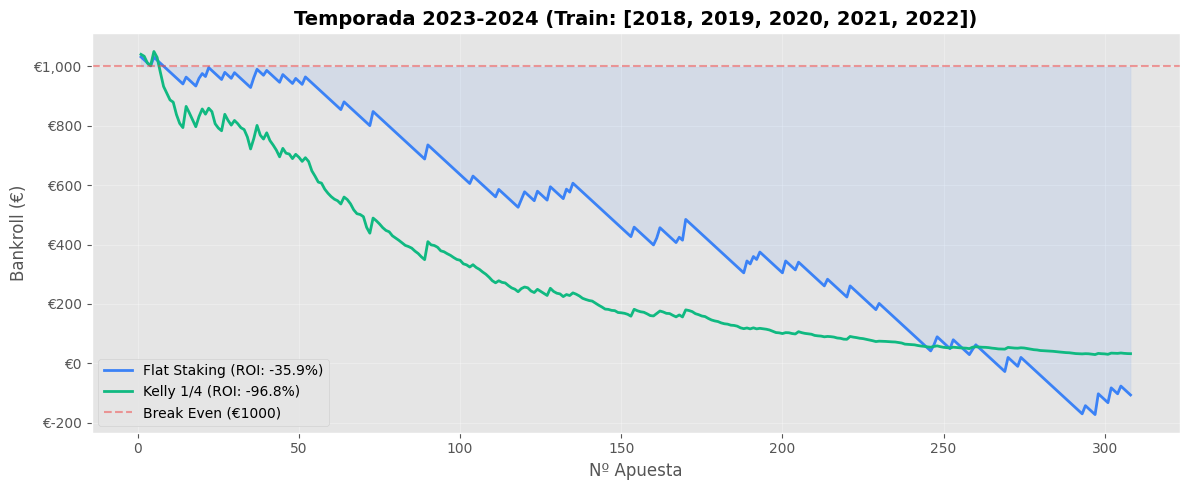


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2023-08-11 00:00:00,Sevilla FC vs Valencia CF,A,4.20,16.3%,€12.70,WIN,€40.65
2023-08-11 00:00:00,UD Almeria vs Rayo Vallecano,D,3.30,5.7%,€6.46,LOSS,€-6.46
2023-08-12 00:00:00,Real Sociedad vs Girona FC,A,5.25,38.0%,€23.13,LOSS,€-23.13
2023-08-12 00:00:00,Athletic Club vs Real Madrid,H,3.30,7.0%,€7.69,LOSS,€-7.69
2023-08-13 00:00:00,Celta Vigo vs CA Osasuna,A,3.90,18.7%,€16.20,WIN,€46.99
2024-05-25 00:00:00,UD Almeria vs Cadiz CF,D,3.60,16.0%,€0.52,LOSS,€-0.52
2024-05-25 00:00:00,CA Osasuna vs Villarreal CF,D,3.60,15.8%,€0.50,WIN,€1.31
2024-05-26 00:00:00,UD Las Palmas vs Alaves,A,3.00,27.9%,€1.21,LOSS,€-1.21
2024-05-26 00:00:00,Sevilla FC vs FC Barcelona,H,4.00,27.5%,€0.77,LOSS,€-0.77
2024-05-26 00:00:00,Celta Vigo vs Valencia CF,A,3.80,11.8%,€0.34,LOSS,€-0.34



────────────────────────────────────────────────────────────
TEMPORADA 2024-2025
Entrenado con: [2019, 2020, 2021, 2022, 2023]
────────────────────────────────────────────────────────────
  Apuestas: 313  |  Aciertos: 57 (18.2%)
  ROI Flat: -13.03%  |  Bankroll: €592
  ROI Kelly: -84.05%  |  Bankroll: €159

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     A   182    29   15.9%   -10.7%
     D    21     5   23.8%   -17.4%
     H   110    23   20.9%   -16.1%


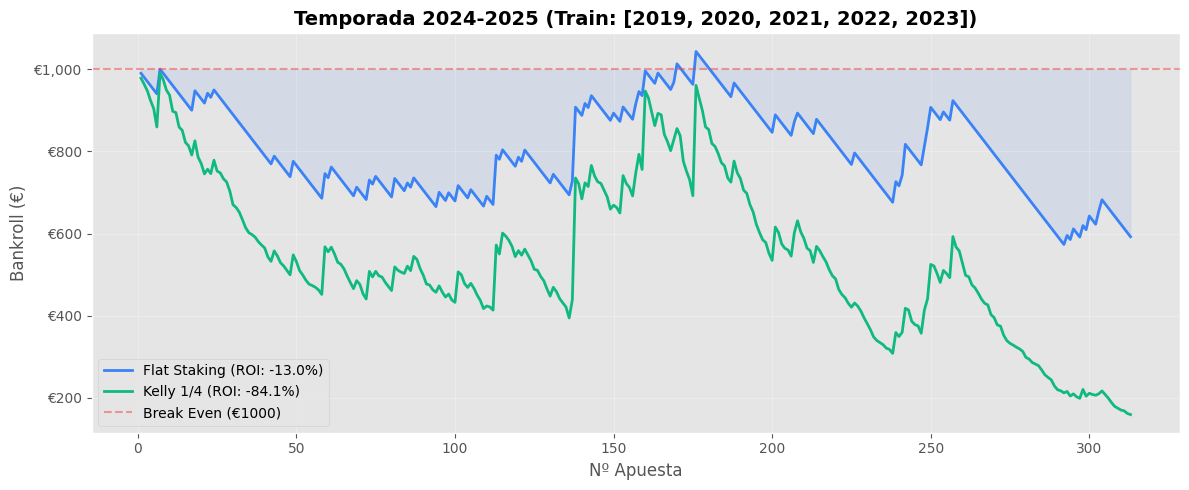


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2024-08-15 00:00:00,Athletic Club vs Getafe CF,A,8.00,61.4%,€21.94,LOSS,€-21.94
2024-08-16 00:00:00,Celta Vigo vs Alaves,A,4.10,18.9%,€14.89,LOSS,€-14.89
2024-08-16 00:00:00,UD Las Palmas vs Sevilla FC,H,2.80,11.7%,€15.72,LOSS,€-15.72
2024-08-17 00:00:00,Valencia CF vs FC Barcelona,H,4.75,37.5%,€23.70,LOSS,€-23.70
2024-08-17 00:00:00,CA Osasuna vs CD Leganes,A,4.50,29.8%,€19.63,LOSS,€-19.63
2025-05-24 00:00:00,Real Madrid vs Real Sociedad,A,6.50,55.1%,€4.49,LOSS,€-4.49
2025-05-24 00:00:00,Alaves vs CA Osasuna,H,3.20,23.2%,€4.62,LOSS,€-4.62
2025-05-25 00:00:00,Girona FC vs Ath Madrid,H,3.80,12.2%,€1.86,LOSS,€-1.86
2025-05-25 00:00:00,Villarreal CF vs Sevilla FC,A,6.00,75.4%,€6.35,LOSS,€-6.35
2025-05-25 00:00:00,Athletic Club vs FC Barcelona,H,3.20,14.6%,€2.69,LOSS,€-2.69



────────────────────────────────────────────────────────────
TEMPORADA 2025-2026
Entrenado con: [2020, 2021, 2022, 2023, 2024]
────────────────────────────────────────────────────────────
  Apuestas: 239  |  Aciertos: 113 (47.3%)
  ROI Flat: +51.53%  |  Bankroll: €2232
  ROI Kelly: +4437.58%  |  Bankroll: €45376

  Desglose por tipo de apuesta:
  Tipo     N  Wins    Hit%     ROI%
     D     3     1   33.3%   +25.0%
     H   236   112   47.5%   +51.9%


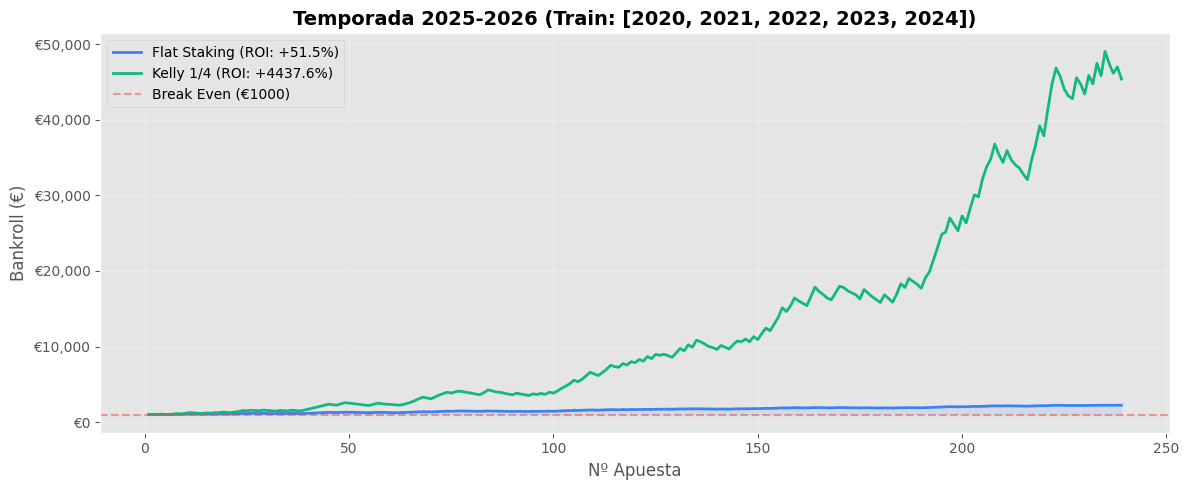


  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<


date,Match,bet,odds,ev,kelly_stake,Result,Profit
2025-08-15 00:00:00,Villarreal vs Oviedo,H,3.20,18.6%,€21.18,WIN,€46.61
2025-08-15 00:00:00,Girona vs Vallecano,H,3.20,19.5%,€23.24,LOSS,€-23.24
2025-08-16 00:00:00,Mallorca vs Barcelona,H,3.20,18.6%,€21.68,LOSS,€-21.68
2025-08-16 00:00:00,Alaves vs Levante,H,3.20,21.6%,€24.58,WIN,€54.08
2025-08-16 00:00:00,Valencia vs Sociedad,H,3.20,21.8%,€26.11,LOSS,€-26.11
2026-02-15 00:00:00,Vallecano vs Ath Madrid,H,3.20,28.0%,€1455.51,WIN,€3202.12
2026-02-15 00:00:00,Levante vs Valencia,H,3.20,28.8%,€1601.74,LOSS,€-1601.74
2026-02-15 00:00:00,Mallorca vs Betis,H,3.20,23.8%,€1282.98,LOSS,€-1282.98
2026-02-16 00:00:00,Girona vs Barcelona,H,3.20,7.2%,€379.87,WIN,€835.71
2026-02-18 00:00:00,Levante vs Villarreal,H,3.20,29.8%,€1590.13,LOSS,€-1590.13



RESUMEN GLOBAL — TODAS LAS TEMPORADAS


,bets,wins,hit_rate,flat_roi,flat_final,kelly_roi,kelly_final
season,,,,,,,
2015,309,56,18.1,-17.45,461.0,-84.08,159.0
2016,316,50,15.8,-23.99,242.0,-91.02,90.0
2017,313,74,23.6,-0.06,998.0,-66.99,330.0
2018,323,81,25.1,12.70,1410.0,278.04,3780.0
2019,303,59,19.5,-16.66,495.0,-87.21,128.0
2020,316,63,19.9,-8.30,738.0,-64.30,357.0
2021,311,56,18.0,-18.20,434.0,-86.95,130.0
2022,307,75,24.4,0.96,1030.0,-31.27,687.0
2023,308,49,15.9,-35.94,-107.0,-96.78,32.0



Media ROI Flat: -6.22%
Total apuestas: 3358
Total aciertos: 733 (21.8%)


In [16]:
# ============================================================
# BACKTEST: Walk-Forward por Temporadas con Apuestas Combinadas
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import log_loss, accuracy_score

# --- Configuración ---
INITIAL_BANKROLL = 1000
FLAT_STAKE = 10
MIN_EV = 0.05        # Solo apostar si EV > 5%
KELLY_FRACTION = 0.25 # Cuarto Kelly (más conservador)
WINDOW_SIZE = 5       # Años de entrenamiento

# --- Preparar datos ---
df_bt = df.copy()

# DEDUPLICAR: Season 2024 contiene filas duplicadas (3040 vs 380 esperadas)
# Identificamos duplicados por Date + HomeTeam + AwayTeam y nos quedamos con el primero
before = len(df_bt)
df_bt = df_bt.drop_duplicates(subset=['Date', 'HomeTeam', 'AwayTeam'], keep='first')
after = len(df_bt)
if before != after:
    print(f"⚠️ Se eliminaron {before - after} filas duplicadas ({before} → {after})")

odds_cols = ['B365H', 'B365D', 'B365A']

# Verificar que las cuotas existen
has_odds = all(c in df_bt.columns for c in odds_cols)
if not has_odds:
    print('⚠️ Columnas de cuotas B365 no encontradas. Backtest no disponible.')
else:
    # Eliminar filas sin cuotas
    df_bt = df_bt.dropna(subset=odds_cols + features + ['Target'])
    df_bt = df_bt.sort_values('Date').reset_index(drop=True)
    
    # --- Walk-Forward por Temporadas ---
    seasons_bt = sorted(df_bt['Season'].unique())
    n_folds = len(seasons_bt) - WINDOW_SIZE
    
    print(f"\n{'='*60}")
    print(f"WALK-FORWARD BACKTEST — {n_folds} Temporadas de Test")
    print(f"Ventana de entrenamiento: {WINDOW_SIZE} años")
    print(f"Temporadas disponibles: {seasons_bt}")
    print(f"{'='*60}")
    
    all_season_results = {}  # dict: season -> list of bet results
    
    for fold_i in range(n_folds):
        fold = fold_i + 1
        train_seasons = seasons_bt[fold_i : fold_i + WINDOW_SIZE]
        test_season   = seasons_bt[fold_i + WINDOW_SIZE]
        
        train_mask = df_bt['Season'].isin(train_seasons)
        test_mask  = df_bt['Season'] == test_season
        
        X_train_f = df_bt.loc[train_mask, features].astype(float)
        y_train_f = df_bt.loc[train_mask, 'Target'].astype(int)
        X_test_f  = df_bt.loc[test_mask,  features].astype(float)
        y_test_f  = df_bt.loc[test_mask,  'Target'].astype(int)
        
        n_train = len(X_train_f)
        n_test  = len(X_test_f)
        
        # --- Entrenar modelo ---
        _params = best_params if 'best_params' in dir() else {
            'objective': 'multi:softprob', 'num_class': 3, 'max_depth': 4,
            'learning_rate': 0.05, 'n_estimators': 150, 'random_state': 42
        }
        bt_model = xgb.XGBClassifier(**_params)
        bt_model.fit(X_train_f, y_train_f)
        
        # --- Predecir ---
        proba = bt_model.predict_proba(X_test_f)
        preds = bt_model.predict(X_test_f)
        ll = log_loss(y_test_f, proba)
        acc = accuracy_score(y_test_f, preds)
        
        print(f"\n--- Fold {fold}: Train {train_seasons} → Test {int(test_season)} "
              f"({n_train} train, {n_test} test) ---")
        print(f"    Log Loss: {ll:.4f} | Accuracy: {acc:.4f}")
        
        # --- Evaluar apuestas ---
        test_indices = df_bt.index[test_mask].tolist()
        season_results = []
        
        for j, idx in enumerate(test_indices):
            row = df_bt.iloc[idx]
            p_A, p_D, p_H = proba[j]  # Mapping: A=0, D=1, H=2
            
            odds_H = row['B365H']
            odds_D = row['B365D']
            odds_A = row['B365A']
            actual = int(row['Target'])  # 0=A, 1=D, 2=H
            
            # === APUESTAS SIMPLES ===
            bets = []
            # Home win
            bets.append(('H', p_H, odds_H, actual == 2))
            # Draw
            bets.append(('D', p_D, odds_D, actual == 1))
            # Away win
            bets.append(('A', p_A, odds_A, actual == 0))
            
            # === APUESTAS COMBINADAS (Doble Oportunidad) ===
            # 1X = Home o Draw
            p_1X = p_H + p_D
            odds_1X = 1.0 / (1.0/odds_H + 1.0/odds_D)
            bets.append(('1X', p_1X, odds_1X, actual in (1, 2)))
            
            # X2 = Draw o Away
            p_X2 = p_D + p_A
            odds_X2 = 1.0 / (1.0/odds_D + 1.0/odds_A)
            bets.append(('X2', p_X2, odds_X2, actual in (0, 1)))
            
            # 12 = Home o Away
            p_12 = p_H + p_A
            odds_12 = 1.0 / (1.0/odds_H + 1.0/odds_A)
            bets.append(('12', p_12, odds_12, actual in (0, 2)))
            
            # --- Calcular EV y elegir la mejor ---
            best_bet = None
            best_ev_val = -999
            for (bet_name, prob, odds_val, won) in bets:
                ev = (prob * odds_val) - 1
                if ev > best_ev_val:
                    best_ev_val = ev
                    best_bet = (bet_name, prob, odds_val, won, ev)
            
            if best_bet is not None and best_ev_val > MIN_EV:
                bet_name, prob, odds_val, won, ev = best_bet
                kelly = max(0, (prob * odds_val - 1) / (odds_val - 1)) * KELLY_FRACTION
                
                season_results.append({
                    'date': row['Date'],
                    'home': row.get('HomeTeam', ''),
                    'away': row.get('AwayTeam', ''),
                    'bet': bet_name,
                    'odds': odds_val,
                    'prob': prob,
                    'ev': ev,
                    'won': won,
                    'kelly_pct': kelly,
                    'fold': fold
                })
        
        all_season_results[int(test_season)] = season_results
        print(f"    Apuestas con EV > {MIN_EV*100:.0f}%: {len(season_results)}")

    # ================================================================
    # GRÁFICAS POR TEMPORADA
    # ================================================================
    print(f"\n{'='*60}")
    print("RESULTADOS POR TEMPORADA")
    print(f"{'='*60}")
    
    global_summary = []
    
    for season_year in sorted(all_season_results.keys()):
        results = all_season_results[season_year]
        if not results:
            print(f"\nTemporada {season_year}: Sin apuestas con EV > {MIN_EV*100:.0f}%")
            continue
        
        df_res = pd.DataFrame(results)
        df_res['date'] = pd.to_datetime(df_res['date'])
        df_res = df_res.sort_values('date').reset_index(drop=True)
        
        # Flat staking P&L
        df_res['flat_pnl'] = df_res.apply(
            lambda r: FLAT_STAKE * (r['odds'] - 1) if r['won'] else -FLAT_STAKE, axis=1
        )
        df_res['flat_cumsum'] = INITIAL_BANKROLL + df_res['flat_pnl'].cumsum()
        
        # Kelly P&L
        kelly_bank = INITIAL_BANKROLL
        kelly_curve = []
        kelly_stakes = []
        
        for _, r in df_res.iterrows():
            stake = kelly_bank * r['kelly_pct']
            kelly_stakes.append(stake)
            if r['won']:
                kelly_bank += stake * (r['odds'] - 1)
            else:
                kelly_bank -= stake
            kelly_curve.append(kelly_bank)
        
        df_res['kelly_cumsum'] = kelly_curve
        df_res['kelly_stake'] = kelly_stakes
        
        # --- Métricas ---
        total_bets = len(df_res)
        wins = int(df_res['won'].sum())
        hit_rate = wins / total_bets * 100
        flat_roi = df_res['flat_pnl'].sum() / (total_bets * FLAT_STAKE) * 100
        kelly_roi = (kelly_bank - INITIAL_BANKROLL) / INITIAL_BANKROLL * 100
        flat_final = df_res['flat_cumsum'].iloc[-1]
        
        # Desglose por tipo de apuesta
        bet_breakdown = df_res.groupby('bet').agg(
            n=('won', 'count'),
            wins=('won', 'sum'),
            pnl=('flat_pnl', 'sum')
        )
        bet_breakdown['hit'] = (bet_breakdown['wins'] / bet_breakdown['n'] * 100).round(1)
        bet_breakdown['roi'] = (bet_breakdown['pnl'] / (bet_breakdown['n'] * FLAT_STAKE) * 100).round(1)
        
        # Temporadas de entrenamiento usadas
        fold_idx = season_year - seasons_bt[WINDOW_SIZE]
        train_used = seasons_bt[fold_idx : fold_idx + WINDOW_SIZE]
        
        print(f"\n{'─'*60}")
        print(f"TEMPORADA {season_year}-{season_year+1}")
        print(f"Entrenado con: {list(map(int, train_used))}")
        print(f"{'─'*60}")
        print(f"  Apuestas: {total_bets}  |  Aciertos: {wins} ({hit_rate:.1f}%)")
        print(f"  ROI Flat: {flat_roi:+.2f}%  |  Bankroll: €{flat_final:.0f}")
        print(f"  ROI Kelly: {kelly_roi:+.2f}%  |  Bankroll: €{kelly_bank:.0f}")
        print(f"\n  Desglose por tipo de apuesta:")
        print(f"  {'Tipo':>4s}  {'N':>4s}  {'Wins':>4s}  {'Hit%':>6s}  {'ROI%':>7s}")
        for bt_name, bt_row in bet_breakdown.iterrows():
            print(f"  {bt_name:>4s}  {int(bt_row['n']):>4d}  {int(bt_row['wins']):>4d}  "
                  f"{bt_row['hit']:>5.1f}%  {bt_row['roi']:>+6.1f}%")
        
        global_summary.append({
            'season': f"{season_year}",
            'bets': total_bets,
            'wins': wins,
            'hit_rate': round(hit_rate, 1),
            'flat_roi': round(flat_roi, 2),
            'flat_final': round(flat_final, 0),
            'kelly_roi': round(kelly_roi, 2),
            'kelly_final': round(kelly_bank, 0)
        })
        
        # === GRÁFICA POR TEMPORADA ===
        fig, ax = plt.subplots(figsize=(12, 5))
        
        bet_numbers = range(1, total_bets + 1)
        
        ax.plot(bet_numbers, df_res['flat_cumsum'], 
                label=f'Flat Staking (ROI: {flat_roi:+.1f}%)', 
                color='#3b82f6', linewidth=2)
        ax.plot(bet_numbers, df_res['kelly_cumsum'], 
                label=f'Kelly 1/4 (ROI: {kelly_roi:+.1f}%)', 
                color='#10b981', linewidth=2)
        ax.axhline(y=INITIAL_BANKROLL, color='#ef4444', linestyle='--', 
                   alpha=0.5, label='Break Even (€1000)')
        ax.fill_between(bet_numbers, INITIAL_BANKROLL, df_res['flat_cumsum'], 
                        alpha=0.1, color='#3b82f6')
        
        ax.set_title(f'Temporada {season_year}-{season_year+1} '
                     f'(Train: {list(map(int, train_used))})', 
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Nº Apuesta')
        ax.set_ylabel('Bankroll (€)')
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('€{x:,.0f}'))
        plt.tight_layout()
        plt.show()

        # === TABLA DETALLE DE APUESTAS ===
        print(f"\n  >>> Detalle de Apuestas (Muestra: 5 primeras + 5 últimas) <<<")
        df_disp = df_res.copy()
        df_disp['Match'] = df_disp['home'] + ' vs ' + df_disp['away']
        df_disp['Result'] = df_disp['won'].map({True: 'WIN', False: 'LOSS'})
        df_disp['Profit'] = df_disp.apply(lambda r: r['kelly_stake'] * (r['odds'] - 1) if r['won'] else -r['kelly_stake'], axis=1)
        
        cols_show = ['date', 'Match', 'bet', 'odds', 'ev', 'kelly_stake', 'Result', 'Profit']
        
        # Formato para mostrar
        format_dict = {'ev': '{:.1%}', 'kelly_stake': '€{:.2f}', 'Profit': '€{:.2f}', 'odds': '{:.2f}'}
        
        if len(df_disp) > 10:
            df_show = pd.concat([df_disp[cols_show].head(5), df_disp[cols_show].tail(5)])
        else:
            df_show = df_disp[cols_show]
            
        # Check if we are in an IPython environment for display(), else print
        try:
             # Just simple styling if display is available (it is in Jupyter)
             display(df_show.style.format(format_dict).hide(axis='index'))
        except:
             print(df_show.to_string())

    # === TABLA RESUMEN GLOBAL ===
    if global_summary:
        print(f"\n{'='*60}")
        print("RESUMEN GLOBAL — TODAS LAS TEMPORADAS")
        print(f"{'='*60}")
        df_summary = pd.DataFrame(global_summary)
        display(df_summary.set_index('season'))
        
        avg_roi = df_summary['flat_roi'].mean()
        total_bets_all = df_summary['bets'].sum()
        total_wins_all = df_summary['wins'].sum()
        print(f"\nMedia ROI Flat: {avg_roi:+.2f}%")
        print(f"Total apuestas: {total_bets_all}")
        print(f"Total aciertos: {total_wins_all} ({total_wins_all/total_bets_all*100:.1f}%)")


## 📊 Backtest: Simulación de Apuestas

Validación financiera del modelo mediante simulación retrospectiva:
- **Apuesta plana** (10u por apuesta) vs **Kelly Criterion** (stake proporcional al edge)
- Solo se apuesta cuando **EV > 5%** (margen de seguridad)
- Se utilizan cuotas históricas de Bet365 (`B365H`, `B365D`, `B365A`)

> ⚠️ Este backtest usa el mismo dataset de entrenamiento (in-sample). Para una validación rigurosa out-of-sample, ver Notebook 03.

In [17]:
# [CELDA ELIMINADA — Backtest consolidado en celda anterior]
